In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db = sqlite3.connect("C:\\Users\\Lenovo\\Desktop\\Studia\\WSzI\\deep-learning-project\\data\\chembl_36\\chembl_36_sqlite\\chembl_36.db")

def query(sql: str):
    return pd.read_sql(sql, db)

Molecules: 2878135
Activities: 24267312
Assays: 1890749
Targets: 17803


## Molecules
Neutralne elektrycznie grupy dwóch lub więcej atomów, które sąpołączone wiązaniami chemicznymi, tworząc najmniejszą stabilną cząstke substancji zachowującą jej właściwości chemiczne

## Activities
Są to wyniki eksperymentów biologicznych, zawiera konkretne wyniki bioaktywności

## Assays
To eksperyment lub test biologiczy

## Targets
To cele biologiczne, tu są wszystkie białka, komórki, organizmy, na które działają molekuły


In [7]:
print("Molecules:", query("SELECT COUNT(*) AS n FROM molecule_dictionary")["n"][0])
print("Activities:", query("SELECT COUNT(*) AS n FROM activities")["n"][0])
print("Assays:", query("SELECT COUNT(*) AS n FROM assays")["n"][0])
print("Targets:", query("SELECT COUNT(*) AS n FROM target_dictionary")["n"][0])

Molecules: 2878135
Activities: 24267312
Assays: 1890749
Targets: 17803


## Faza kliniczna
Etap badań leku na ludziach, na jakim poziomie rozwoju znajduje się dany kandydat na lek

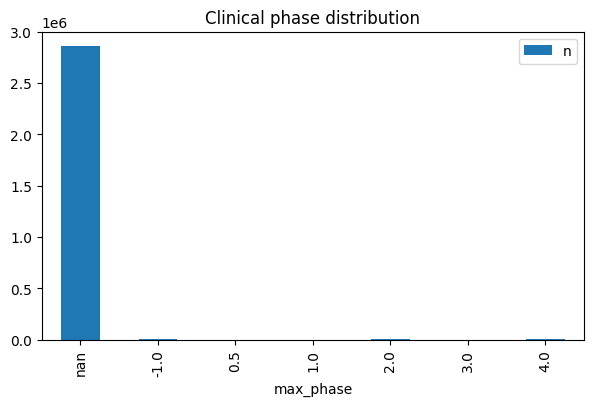

,max_phase,n
0,NaN,2858825
1,-1.0,2530
2,0.5,26
3,1.0,1616
4,2.0,9150
5,3.0,1983
6,4.0,4005


In [8]:
df = query("""
            SELECT max_phase, COUNT(*) as n
           from molecule_dictionary
           group by max_phase
           order by max_phase          
           """)

df.plot.bar(x = 'max_phase', y='n', title="Clinical phase distribution", figsize=(7,4))
plt.show()
df

## Masa molowa
To masa jednego mola danej substancji chemicznej, wyrażana zazwyczja w gramach na mol (g/mol). Jest to wielkość fizyczna, która liczbowo jest równa masie cząsteczkowej (dla cząsteczek) lub masie atomowej (dla atomów)

Powiązanie z molekułą po `molregno`

           full_mwt
count  2.858458e+06
mean   4.430681e+02
std    2.597625e+02
min    4.000000e+00
25%    3.331700e+02
50%    4.044400e+02
75%    4.874700e+02
max    1.254632e+04


<Axes: title={'center': 'Molecular Weight Distribution'}, ylabel='Frequency'>

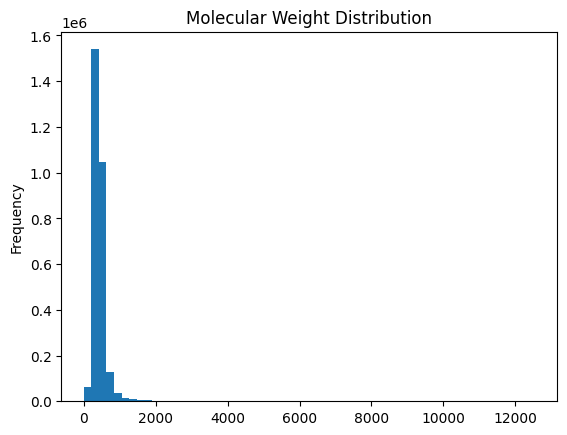

In [9]:
df_mwt = query("SELECT full_mwt from compound_properties WHERE full_mwt is not null")

print(df_mwt.describe())

df_mwt["full_mwt"].plot.hist(bins=60, title="Molecular Weight Distribution")

## logP
Logarytm dziesiętny wspólczynnika podziału między oktanol a wodę

- logP > 0 - cząsteczka hydrofobowa, lubi tłuszcze, słabo rozpuszcza się w wodzie
- logP < 0 - cząsteczka hydrofilowa, dobrze rozpuszcza się w wodzie
- logP ~~ 2-3 - często optymalne dla leków doustnych (wg Lipińskiego)

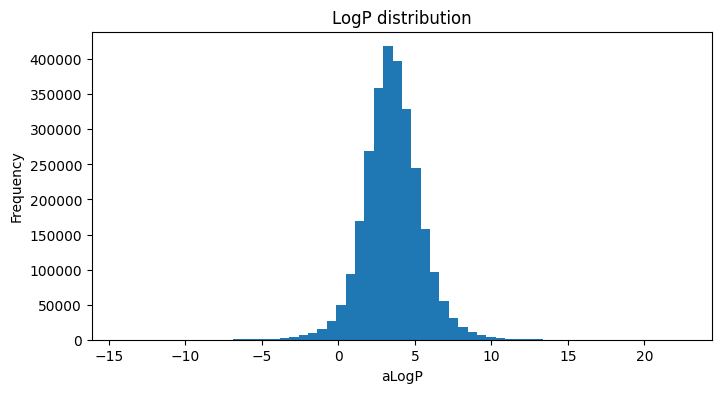

,alogp
count,2.784347e+06
mean,3.524149e+00
std,1.868393e+00
min,-1.426000e+01
25%,2.400000e+00
50%,3.490000e+00
75%,4.630000e+00
max,2.257000e+01


In [10]:
df_logp = query ("SELECT alogp from compound_properties where alogp is not null;")

df_logp['alogp'].plot.hist(bins=60, figsize=(8,4), title="LogP distribution")
plt.xlabel("aLogP")
plt.show()
df_logp.describe()

## Targety

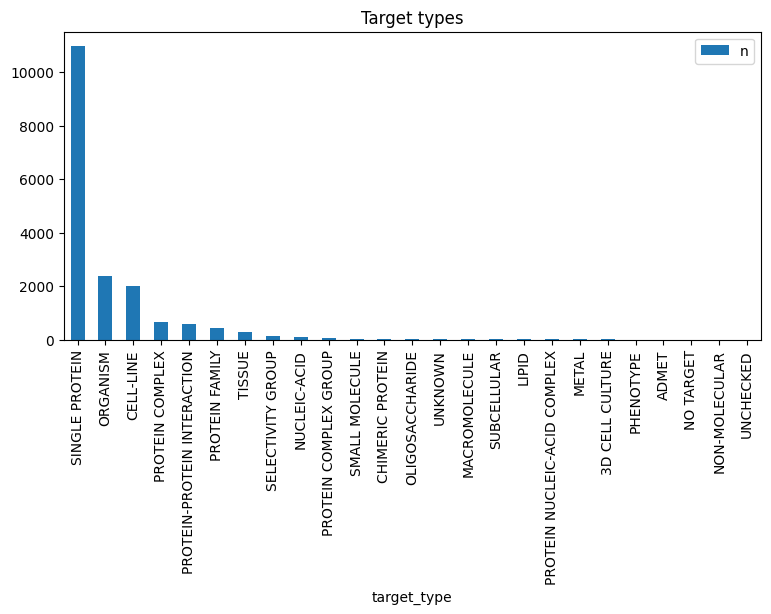

,target_type,n
0,SINGLE PROTEIN,10962
1,ORGANISM,2383
2,CELL-LINE,1997
3,PROTEIN COMPLEX,645
4,PROTEIN-PROTEIN INTERACTION,596
5,PROTEIN FAMILY,428
6,TISSUE,294
7,SELECTIVITY GROUP,123
8,NUCLEIC-ACID,112
9,PROTEIN COMPLEX GROUP,66


In [11]:
df_ttypes = query("select target_type, count(*) as n from target_dictionary group by target_type order by n desc;")
df_ttypes.plot.bar(x="target_type", y="n", figsize=(9,4), title="Target types")
plt.show()
df_ttypes

## Organizmy
docelowe

In [ ]:
df_org = query("select organism, count(*) as n from target_dictionary group by organism order by n desc;")